# 🫀🩺⚕️ **Heart disease prediction**

### **Introduction**

**Aim**: predict a probability for the Heart Disease.
**Evaluation**: area under de ROC curve between the predicted probability and the observed target.
**Original dataset**. https://www.kaggle.com/datasets/neurocipher/heartdisease/data

### **Schema**
* 📑 1. First steps](#first-steps)
* 🔍 2. Exploratory Data Analysis (EDA)
    * a. 📊 Dataset overview**..
    * b. 🎯 Target distribution.
    * c. 📈Numerical features analysis.
    * d. 🏷 Categorical features analysis.
    * e. 🔗 Feature associations.
    * f. 📌 EDA conclusions.
* 🛠 3. Feature Engineering
    * a. 📐Train regression models.
    * b. 🔁 Test regression models.
* 🤖 4. Modeling
    * a. 🔹 Logistic Regression (L2 Regularization).
    * b. 🔹 Logistic Regression (ElasticNet).
    * c. 🔹 Random Forest.
    * d. 🔹 LightGBM.
    * e. 🎯 Model Comparison.
    * f. 📌 Models conclusions.
* 🏆 5. Final model
   

### **Features**
* **Heart Disease**. TARGET.
* **Age**. Numerical. Age of the patient (in years)
* **Sex**. Boolean. Gender of the patient (1 = Male, 0 = Female)
* **Chest pain type**. Categorical. Type of chest pain:
    * 1 = Typical angina
    * 2 = Atypical angina
    * 3 = Non-anginal pain
    * 4 = Asymptomatic
* **BP**. Numerical. Resting blood pressure (mm Hg)
* **Cholesterol**. Numerical. Serum cholesterol level (mg/dL)
* **FBS over 120**. Boolean. Fasting blood sugar > 120 mg/dL (1 = True, 0 = False)
* **EKG results**. Categorical. Resting electrocardiogram results:
    * 0 = Normal
    * 1 = ST-T wave abnormality
    * 2 = Left ventricular hypertrophy
* **Max HR**. Numerical. Maximum heart rate achieved
* **Exercise angina**. Boolean. Exercise-induced angina (1 = Yes, 0 = No)
* **ST depression**. Numerical. ST depression induced by exercise relative to rest
* **Slope of ST**. Categorical. Slope of the peak exercise ST segment
* **Number of vessels fluro**. Categorical. Number of major vessels (0–3) colored by fluoroscopy
* **Thallium**. Categorical. Thallium stress test result (categorical medical indicator)



<a id="first-steps"></a>

# **📑 1. First steps**

* **Import Python libraries**.
* **Data import**. A copy of the original training dataset (train_raw) is preserved to maintain an untouched reference version.
* **Data Type Adjustment and Categorical Mapping**. To improve interpretability during exploratory data analysis, categorical and binary variables were converted from numeric encoding to meaningful labels. *Number of Vessels* (fluoroscopy) was explicitly converted to a categorical data type, as it represents discrete ordinal levels rather than a continuous numeric variable.

In [1]:
 # Packages

# Numerical computation and data handling
import numpy as np      
import pandas as pd 

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Exploratory data analysis (EDA)
from scipy.stats import chi2_contingency, spearmanr, pearsonr, f_oneway
from scipy import stats

# Preprocessing tools and machine learning algorithms
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Gradient boosting modeling
import lightgbm as lgb

# Warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Import data
train = pd.read_csv("/kaggle/input/playground-series-s6e2/train.csv")
test = pd.read_csv("/kaggle/input/playground-series-s6e2/test.csv")

# Original data
train_raw = train.copy()

In [3]:
# Map encoded categorical variables to descriptive labels for EDA

train['Sex'] = train['Sex'].map({
    0: 'Female', 
    1: 'Male'
})
train['Chest pain type'] = train['Chest pain type'].map({
    1: 'Typical angina', 
    2: 'Atypical angina',
    3: 'Non-anginal pain',
    4: 'Asymptomatic'
})  
train['EKG results'] = train['EKG results'].map({
    0: 'Normal', 
    1: 'ST-T wave abnormality',
    2: 'Left ventricular hypertrophy'
})
train['Exercise angina'] = train['Exercise angina'].map({
    0: 'No', 
    1: 'Yes'
})
train['Number of vessels fluro'] = train['Number of vessels fluro'].astype('category')

<a id="eda"></a>

# 🔍 **2. Exploratory Data Analysis (EDA)**

The exploratory data analysis phase aims to understand the structure, composition, and statistical properties of the dataset before modeling. Understanding these aspects ensures appropriate preprocessing and model selection.

1. **📊 Dataset overview**. This step provides an initial inspection of the dataset structure.
2. **🎯 Target distribution**. Understanding the class distribution is essential before model development.
3. **📈Numerical features analysis**. This section explores the distributional properties and statistical behavior of numerical variables in the dataset.
4. **🏷 Categorical features analysis**. Analyzes the behavior of categorical variables in the dataset.
5. **🔗 Feature associations**. This section analyzes the relationships between predictors.
6. **📌 Conclusions**.

## **📊 a. Dataset overview**

First, a random sample of rows is displayed to understand the feature composition and variable formats.

Next, the total number of observations and features is reported to assess dataset size.

Finally, train.info() is used to identify data types and detect missing values

This overview ensures data consistency and allows early detection of structural issues before proceeding with deeper analysis.

In [4]:
train.sample(5)

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
188114,188114,67,Male,Asymptomatic,110,265,0,Left ventricular hypertrophy,165,Yes,1.2,2,0,7,Presence
570121,570121,59,Male,Non-anginal pain,140,288,0,Normal,157,No,1.6,2,1,3,Presence
115610,115610,58,Male,Asymptomatic,120,226,0,Normal,142,Yes,1.5,2,0,7,Presence
181857,181857,66,Male,Atypical angina,110,288,0,Left ventricular hypertrophy,163,No,0.0,1,0,3,Absence
463350,463350,67,Male,Asymptomatic,126,282,0,Normal,148,Yes,2.4,2,1,3,Presence


In [5]:
print(f"There are {train.shape[0]} rows and {train.shape[1]} columns, including the target")

There are 630000 rows and 15 columns, including the target


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   id                       630000 non-null  int64   
 1   Age                      630000 non-null  int64   
 2   Sex                      630000 non-null  object  
 3   Chest pain type          630000 non-null  object  
 4   BP                       630000 non-null  int64   
 5   Cholesterol              630000 non-null  int64   
 6   FBS over 120             630000 non-null  int64   
 7   EKG results              630000 non-null  object  
 8   Max HR                   630000 non-null  int64   
 9   Exercise angina          630000 non-null  object  
 10  ST depression            630000 non-null  float64 
 11  Slope of ST              630000 non-null  int64   
 12  Number of vessels fluro  630000 non-null  category
 13  Thallium                 630000 non-null  in

## **🎯 b. Target distribution**

First, descriptive statistics of the target variable are examined.

Then, absolute and relative class frequencies are computed to assess balance between:

* Presence of heart disease
* Absence of heart disease

A pie chart is used to visually represent the class proportions.

Finnaly, assess *Class Imbalance Assessment*. To quantify imbalance, the imbalance ratio is calculated as:

* Imbalance Ratio = Majority Class / Minority Class 

Interpretation criteria:
* < 1.5 → Balanced dataset
* 1.5 – 3 → Mild imbalance
* \> 3 → Significant imbalance

This metric helps determine whether techniques such as class weighting or resampling are required during model training.

In [7]:
target = 'Heart Disease'

In [8]:
train[target].describe()

count      630000
unique          2
top       Absence
freq       347546
Name: Heart Disease, dtype: object

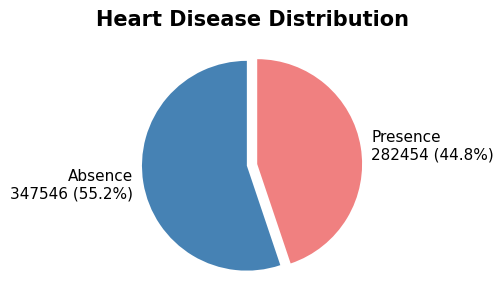

In [9]:
# Requirements
target_counts = train[target].value_counts()
target_pct = train[target].value_counts(normalize=True) * 100

# PIE CHART
plt.figure(figsize=(5, 5))
colors = ['steelblue', 'lightcoral']
explode = (0.05, 0.05)

labels = [f'{label}\n{count} ({count/target_counts.sum()*100:.1f}%)' 
          for label, count in target_counts.items()]

plt.pie(target_counts, 
        labels=labels,
        colors=colors,
        explode=explode,
        startangle=90,
        textprops={'fontsize': 11})

plt.title('Heart Disease Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
"""
IMBALANCE RATIO:
* < 1.5 ok.
* Between 1.5 and 3: mild imbalanced.
* > 3. Significant imbalanced.
"""

absence_count = target_counts['Absence']
presence_count = target_counts['Presence']
imbalance_ratio = absence_count / presence_count
print(f"Imbalance Ratio: {imbalance_ratio:.2f}")
print("\n")

Imbalance Ratio: 1.23




## **📈 c. Numerical features**

The analysis includes:

* Descriptive statistics.
* Distribution visualization.
* Skewness and kurtosis assessment.
* Outlier detection (Boxplot and IQR method).
* Statistical association with the target variable.

 
Understanding these properties is essential for:

* Detecting transformation needs.
* Identifying extreme values.
* Assessing linear separability.
* Supporting model selection decisions.

In [11]:
# Select numerical columns
numerical_features = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

In [12]:
"""
SUMMARY OVERVIEW
Descriptive statistics are computed for all numerical variables, including:

- Mean
- Standard deviation
- Minimum and maximum values
- Quartiles

This provides a first assessment of central tendency and variability, helping identify potential scale differences across features.
"""

train[numerical_features].describe()

,Age,BP,Cholesterol,Max HR,ST depression
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,54.136706,130.497433,245.011814,152.816763,0.716028
std,8.256301,14.975802,33.681581,19.112927,0.948472
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,48.000000,120.000000,223.000000,142.000000,0.000000
50%,54.000000,130.000000,243.000000,157.000000,0.100000
75%,60.000000,140.000000,269.000000,166.000000,1.400000
max,77.000000,200.000000,564.000000,202.000000,6.200000


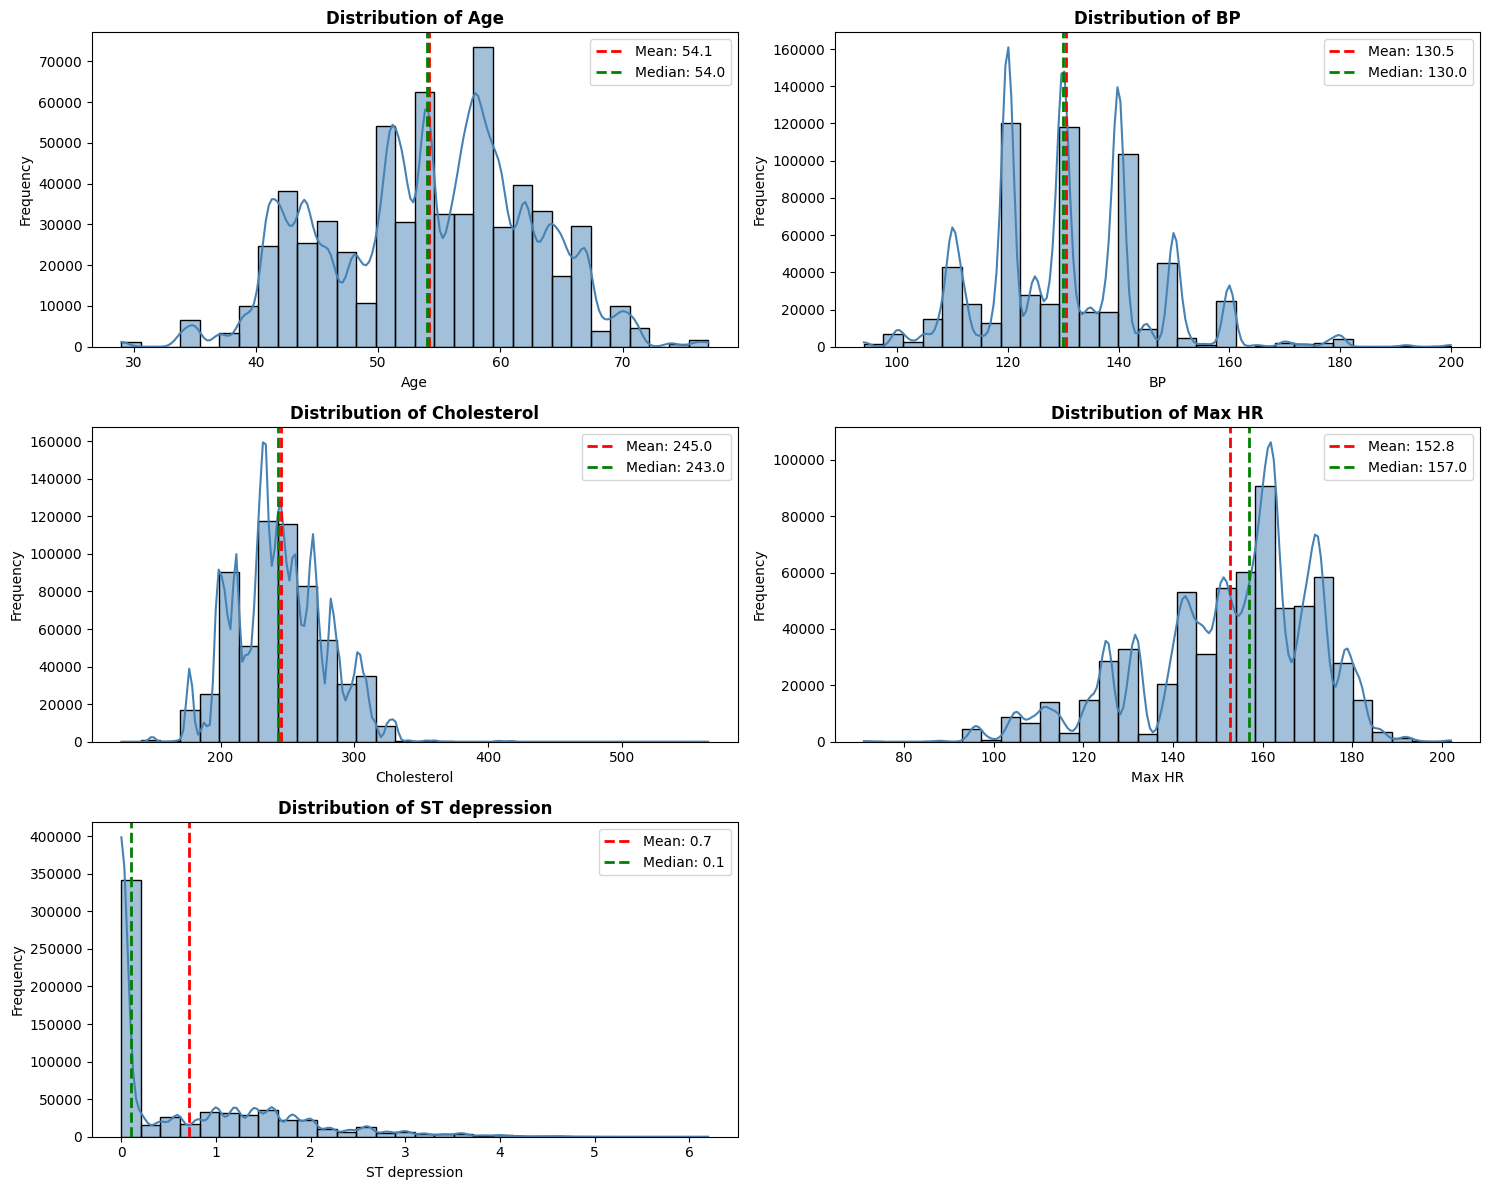

In [13]:
"""
HISTOGRAM. 

Evaluate the shape of each numerical variable.

For each feature:

- Mean and median are displayed to assess symmetry.
- Distribution shape (normal, right-skewed, left-skewed) is visually inspected.

This step is crucial for identifying:

- Potential transformation needs (e.g., log transformation)
- Skewed distributions
- Non-Gaussian behavior
"""

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, feature in enumerate(numerical_features):
    # Histogram with KDE
    sns.histplot(data=train, x=feature, kde=True, ax=axes[idx], color='steelblue', bins=30)
    axes[idx].set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(feature, fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    
    # Add mean and median lines
    mean_val = train[feature].mean()
    median_val = train[feature].median()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
    axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.1f}')
    axes[idx].legend()

# Remove extra subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

In [14]:
"""
SKEWENESS AND KURTOSIS

To formally assess distribution shape, skewness and kurtosis are computed.

Skewness: 
* < -0.5 left-skewed (long tail to the left)   
* Between -0.5 and +0.5 approximtely normal
* > +0.5 right-skewed (long tail to the right) 

Kurtosis:
* < 0.5 Platykurtic
* Between -2 and +2 menokurtic
* > 0.5 Leptokurtic
"""

skew_kurt_data = []

for feature in numerical_features:
    skewness = train[feature].skew()
    kurtosis = train[feature].kurtosis()
    
    skew_kurt_data.append({
        'Feature': feature,
        'Skewness': skewness,
        'Kurtosis': kurtosis
    })

# Create DataFrame
skew_kurt_df = pd.DataFrame(skew_kurt_data)

print(skew_kurt_df.to_string(index=False))


      Feature  Skewness  Kurtosis
          Age -0.164011 -0.570157
           BP  0.629283  0.933183
  Cholesterol  0.273150  0.068237
       Max HR -0.754556  0.203852
ST depression  1.328429  1.374855


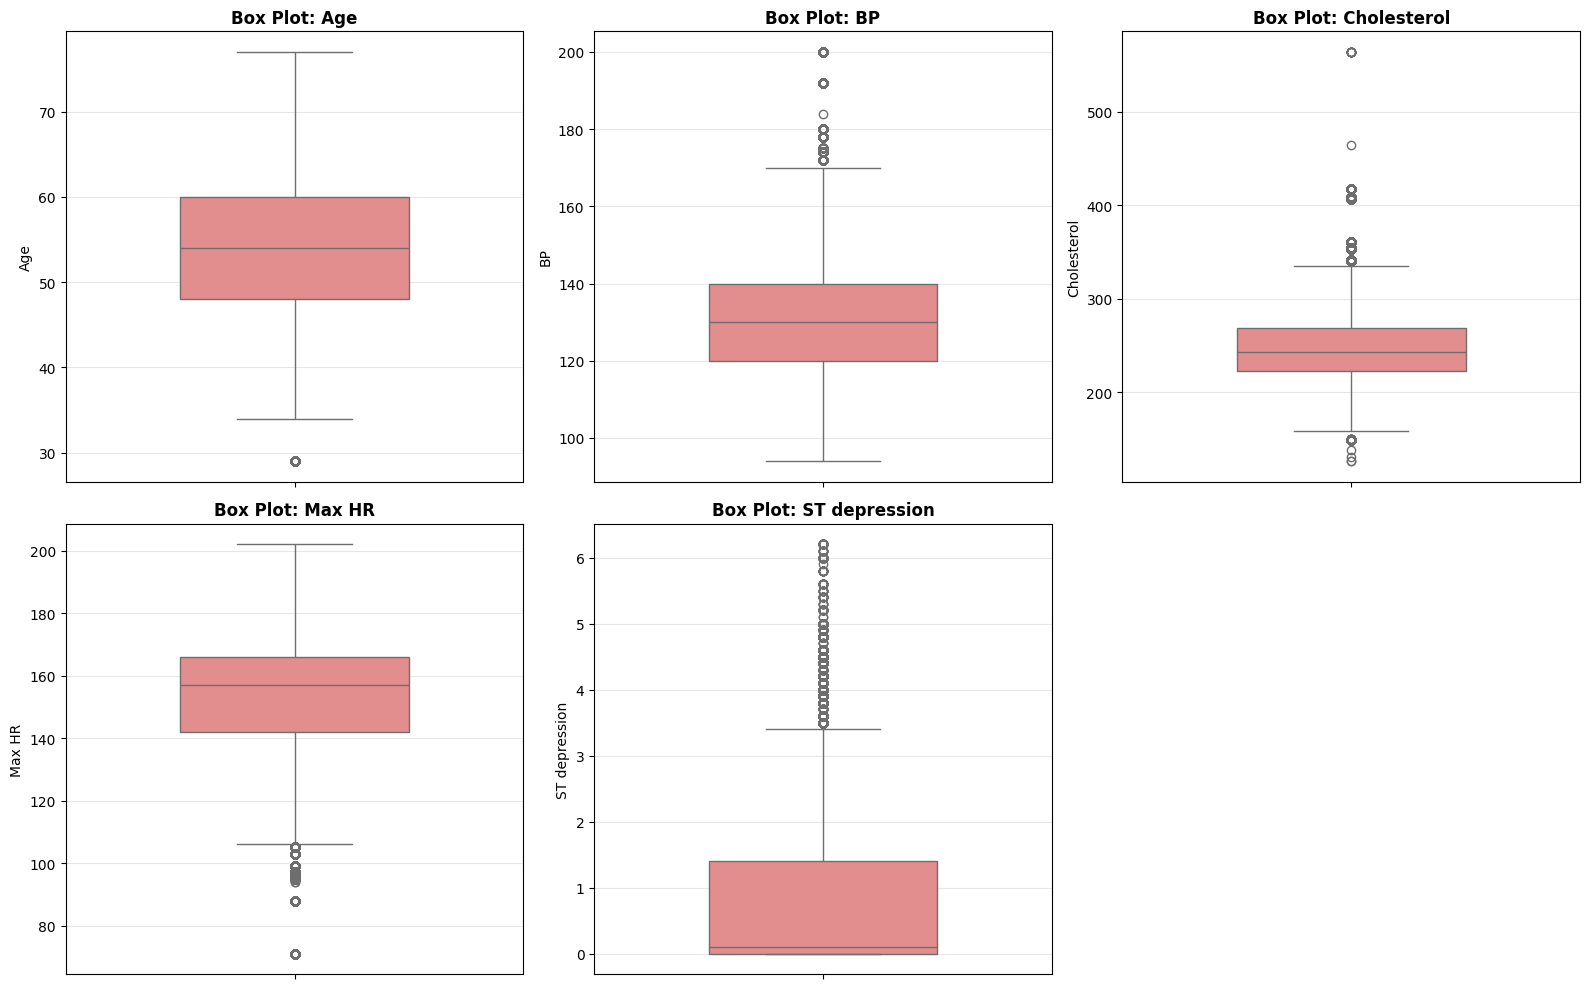

In [15]:
"""
OUTLIERS: Box plot

Visually identify extreme observations
"""

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, feature in enumerate(numerical_features):
    sns.boxplot(data=train, y=feature, ax=axes[idx], color='lightcoral', width=0.5)
    axes[idx].set_title(f'Box Plot: {feature}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(feature, fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)

# Remove extra subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

In [16]:
"""
OUTLIERS: IQR Method

Quantify outliers. The IQR method defines outliers as:

- Lower bound = Q1 − 1.5 × IQR  
- Upper bound = Q3 + 1.5 × IQR  

For each feature, the following are reported:

- Number of lower outliers
- Number of upper outliers
- Total percentage of outliers
"""

# IQR Method - Detect and count outliers
outlier_summary = []

for feature in numerical_features:
    Q1 = train[feature].quantile(0.25)
    Q3 = train[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify outliers
    outliers = train[(train[feature] < lower_bound) | (train[feature] > upper_bound)]
    lower_outliers = train[train[feature] < lower_bound]
    upper_outliers = train[train[feature] > upper_bound]
    
    outlier_summary.append({
        'Feature': feature,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Lower Outliers': len(lower_outliers),
        'Upper Outliers': len(upper_outliers),
        'Total Outliers': len(outliers),
        'Outlier %': round(len(outliers)/len(train)*100, 1)
    })

# Summary
outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))


      Feature    Q1    Q3  IQR  Lower Bound  Upper Bound  Lower Outliers  Upper Outliers  Total Outliers  Outlier %
          Age  48.0  60.0 12.0         30.0         78.0            1048               0            1048        0.2
           BP 120.0 140.0 20.0         90.0        170.0               0            9011            9011        1.4
  Cholesterol 223.0 269.0 46.0        154.0        338.0            1057            1137            2194        0.3
       Max HR 142.0 166.0 24.0        106.0        202.0           14246               0           14246        2.3
ST depression   0.0   1.4  1.4         -2.1          3.5               0            9971            9971        1.6


In [17]:
"""
TARGET ASSOCIATION

To evaluate the relationship between numerical predictors and heart disease status, multiple statistical methods are applied:

* Independent t-test (parametric mean comparison)
* Mann-Whitney U test (non-parametric comparison)
* Point-biserial correlation (continuous vs binary correlation)
* Cohen's d (effect size measurement)

Cohen’s d interpretation:

- < 0.2 → Negligible effect
- 0.2 – 0.5 → Small effect
- 0.5 – 0.8 → Medium effect
- > 0.8 → Large effect
"""

test_results = []

for feature in numerical_features:
    # Separate by target class
    presence = train[train[target] == 'Presence'][feature]
    absence = train[train[target] == 'Absence'][feature]
    
    # Descriptive statistics
    mean_presence = presence.mean()
    mean_absence = absence.mean()
    std_presence = presence.std()
    std_absence = absence.std()
    mean_diff = mean_presence - mean_absence
    
    # T-test
    t_stat, t_pvalue = stats.ttest_ind(presence, absence)
    
    # Mann-Whitney
    u_stat, u_pvalue = stats.mannwhitneyu(presence, absence, alternative='two-sided')
    
    # Point-biserial correlation
    target_binary = (train[target] == 'Presence').astype(int)
    correlation, corr_pvalue = stats.pointbiserialr(target_binary, train[feature])
    
    # Cohen's d
    pooled_std = np.sqrt((std_presence**2 + std_absence**2) / 2)
    cohens_d = mean_diff / pooled_std
    
    # Effect size interpretation
    if abs(cohens_d) < 0.2:
        effect_interpretation = 'Negligible'
    elif abs(cohens_d) < 0.5:
        effect_interpretation = 'Small'
    elif abs(cohens_d) < 0.8:
        effect_interpretation = 'Medium'
    else:
        effect_interpretation = 'Large'
    
    test_results.append({
        'Feature': feature,
        'Mean (Presence)': round(mean_presence, 2),
        'Mean (Absence)': round(mean_absence, 2),
        'Mean Difference': round(mean_diff, 2),
        'Std (Presence)': round(std_presence, 2),
        'Std (Absence)': round(std_absence, 2),
        't-statistic': round(t_stat, 2),
        'p-value': f'{t_pvalue:.4f}' if t_pvalue >= 0.001 else '<0.001',
        'Correlation (r)': round(correlation, 3),
        'Cohen\'s d': round(cohens_d, 3),
        'Effect Size': effect_interpretation,
    })

# DataFrame
results_df = pd.DataFrame(test_results)

# Sort by absolute Cohen's d
results_df['Abs_Cohen_d'] = results_df['Cohen\'s d'].abs()
results_df = results_df.sort_values('Abs_Cohen_d', ascending=False)
results_df = results_df.drop('Abs_Cohen_d', axis=1)

print("\nStatistics by target:")

print(results_df[['Feature', 'Mean (Presence)', 'Mean (Absence)', 'Mean Difference', 
                  'Std (Presence)', 'Std (Absence)']].to_string(index=False))

print("\n\nStatistical tests:")
print(results_df[['Feature', 't-statistic', 'p-value', 'Correlation (r)', 
                  'Cohen\'s d', 'Effect Size']].to_string(index=False))



Statistics by target:
      Feature  Mean (Presence)  Mean (Absence)  Mean Difference  Std (Presence)  Std (Absence)
       Max HR           143.47          160.42           -16.95           19.72          14.74
ST depression             1.17            0.35             0.82            1.07           0.63
          Age            56.08           52.56             3.52            7.77           8.30
  Cholesterol           248.10          242.50             5.60           32.92          34.08
           BP           130.41          130.57            -0.16           14.78          15.14


Statistical tests:
      Feature  t-statistic p-value  Correlation (r)  Cohen's d Effect Size
       Max HR      -389.99  <0.001           -0.441     -0.973       Large
ST depression       378.73  <0.001            0.431      0.936       Large
          Age       172.26  <0.001            0.212      0.438       Small
  Cholesterol        65.91  <0.001            0.083      0.167  Negligible
           

## **🏷 d. Categorical features**

Understanding these relationships helps identify strong predictors and assess redundancy between categorical variables.

The analysis includes:

* Distribution of categories.
* Relationship with the target variable.
* Statistical significance testing.
* Effect size estimation (Cramér's V).

Categorical variables are divided into:

* Binary features
* Multi-category features

In [18]:
# Binary categorical features 
binary_features = ['Sex','FBS over 120','Exercise angina']

# Multi-category categorical features
multicategory_features = ['Chest pain type','EKG results','Slope of ST','Number of vessels fluro','Thallium']

# All categorical features
categorical_features = binary_features + multicategory_features

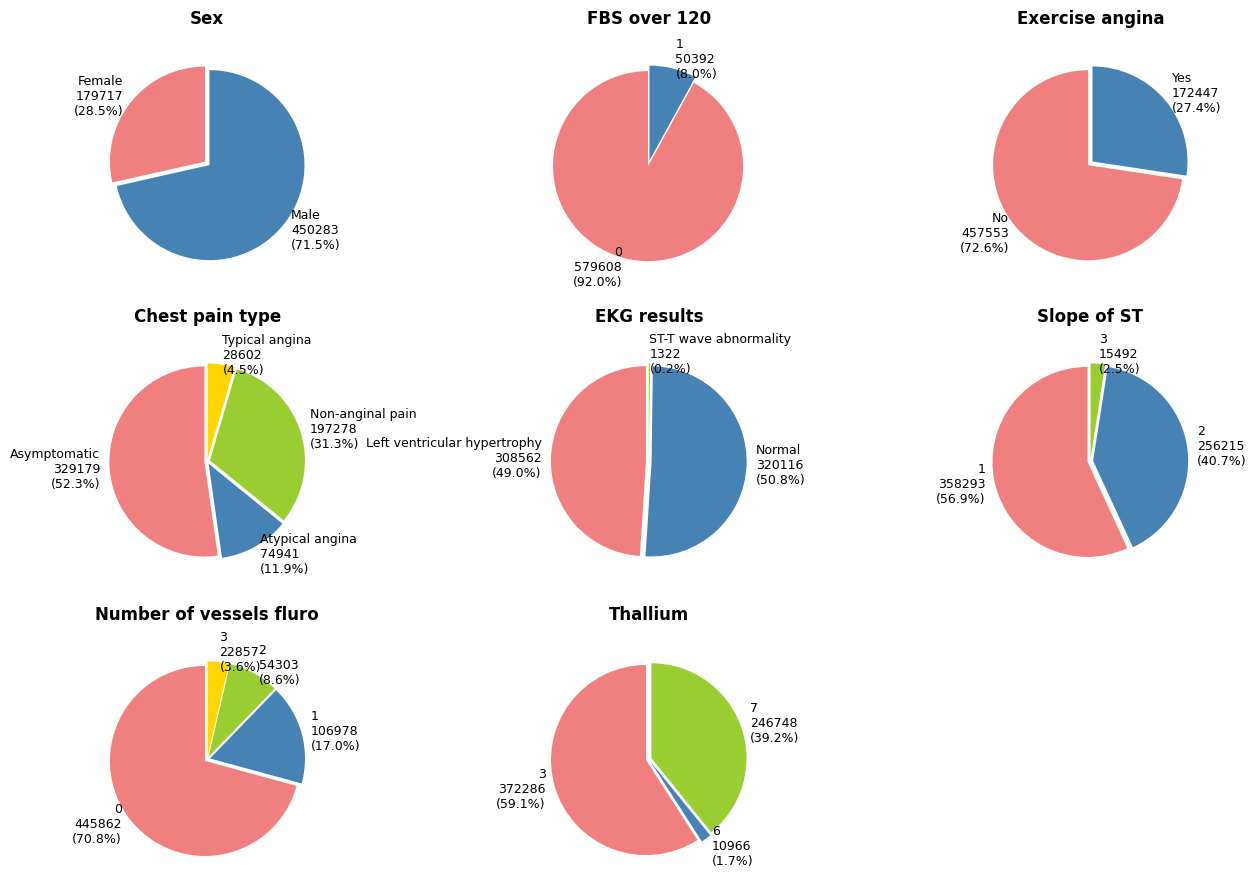

In [19]:
"""
DISTRIBUTION: Pie chart

Visualize the relative frequency of each category within categorical features.

For each variable:

- Absolute counts are displayed.
- Relative percentages are reported.
- Category balance is visually assessed.

This step allows detecting:

- Dominant categories.
- Rare levels.
- Potential imbalance within features.
"""

fig, axes = plt.subplots(3, 3, figsize=(12, 9))
axes = axes.ravel()

color_palettes = {
    3: ['lightcoral', 'steelblue', 'yellowgreen'],
    4: ['lightcoral', 'steelblue', 'yellowgreen', 'gold'],
}

for idx, feature in enumerate(categorical_features):
    ax = axes[idx]
    
    # Get counts
    counts = train[feature].value_counts().sort_index()
    
    # Create custom labels
    labels = [f'{label}\n{count}\n({count/counts.sum()*100:.1f}%)' 
              for label, count in counts.items()]
    
    # Colors
    n_categories = len(counts)
    if feature in binary_features:
        colors = ['lightcoral', 'steelblue'][:n_categories]
    else:
        colors = color_palettes.get(n_categories, plt.cm.Pastel1.colors[:n_categories])
    
    explode = tuple([0.03] * n_categories)
    
    # Create pie chart
    wedges, texts = ax.pie(counts, 
                           labels=labels,
                           colors=colors,
                           explode=explode,
                           startangle=90,
                           textprops={'fontsize': 9}
                           )
    
    ax.set_title(f'{feature}', fontsize=12, fontweight='bold', pad=15)

# Remove extra subplot
fig.delaxes(axes[8])

plt.tight_layout()
plt.show()

In [20]:
"""
RELATIONSHIP with the target

To assess how each categorical feature relates to heart disease, the disease rate within each category is computed.

For each category, the following metrics are reported:

- Total observations
- Number of disease cases
- Number of non-disease cases
- Disease rate (%)

Additionally, the overall disease rate (baseline prevalence) is calculated to serve as a reference point.
"""

# Calculate baseline for reference
overall_disease_rate = (train[target] == 'Presence').sum() / len(train) * 100
print(f"Overall Disease Rate (Baseline): {overall_disease_rate:.1f}%")


relationship_data = []

for feature in categorical_features:
    for category in sorted(train[feature].unique()):
        category_data = train[train[feature] == category]
        
        total_count = len(category_data)
        disease_count = (category_data[target] == 'Presence').sum()
        no_disease_count = (category_data[target] == 'Absence').sum()
        disease_rate = (disease_count / total_count) * 100
        
        relationship_data.append({
            'Feature': feature,
            'Category': category,
            'Total': total_count,
            'Disease': disease_count,
            'No Disease': no_disease_count,
            'Disease Rate (%)': round(disease_rate, 1)
        })

# DataFrame
relationship_df = pd.DataFrame(relationship_data)
print(relationship_df.to_string(index=False))


Overall Disease Rate (Baseline): 44.8%
                Feature                     Category  Total  Disease  No Disease  Disease Rate (%)
                    Sex                       Female 179717    32127      147590              17.9
                    Sex                         Male 450283   250327      199956              55.6
           FBS over 120                            0 579608   257008      322600              44.3
           FBS over 120                            1  50392    25446       24946              50.5
        Exercise angina                           No 457553   143412      314141              31.3
        Exercise angina                          Yes 172447   139042       33405              80.6
        Chest pain type                 Asymptomatic 329179   229595       99584              69.7
        Chest pain type              Atypical angina  74941    12154       62787              16.2
        Chest pain type             Non-anginal pain 197278    37614  

In [21]:
"""
SIGNIFICANT TESTING

Chi-Square Test of independence: H0: Feature and Heart Disease are independent (no association)
* p < 0.05  Significant
* p ≥ 0.05  Not Significant

V Cramer
* 2x2 tables:    < 0.1  : Negligible   0.1-0.3: Small      0.3-0.5: Medium     > 0.5: Large
* Larger tables: < 0.07 : Negligible   0.07-0.21: Small    0.21-0.35: Medium   > 0.35: Large
"""
test_results = []

for feature in categorical_features:
    # Create contingency table
    contingency_table = pd.crosstab(train[feature], train[target])
    
    # Perform chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    # Calculate Cramér's V (effect size)
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape[0] - 1, contingency_table.shape[1] - 1)
    cramers_v = np.sqrt(chi2 / (n * min_dim))
    
    # Effect size interpretation
    if min_dim == 1:  # For 2x2 tables
        if cramers_v < 0.1:
            effect_size = 'Negligible'
        elif cramers_v < 0.3:
            effect_size = 'Small'
        elif cramers_v < 0.5:
            effect_size = 'Medium'
        else:
            effect_size = 'Large'
    else:  # For larger tables
        if cramers_v < 0.07:
            effect_size = 'Negligible'
        elif cramers_v < 0.21:
            effect_size = 'Small'
        elif cramers_v < 0.35:
            effect_size = 'Medium'
        else:
            effect_size = 'Large'
    
    test_results.append({
        'Feature': feature,
        'Chi-Square': round(chi2, 2),
        'Degrees of Freedom': dof,
        'p-value': f'{p_value:.4f}' if p_value >= 0.001 else '<0.001',
        'Cramér\'s V': round(cramers_v, 3),
        'Effect Size': effect_size,
    })

# Create results DataFrame
results_df = pd.DataFrame(test_results)

# Sort by Cramér's V (strongest association first)
results_df = results_df.sort_values('Cramér\'s V', ascending=False)

print(results_df.to_string(index=False))



                Feature  Chi-Square  Degrees of Freedom p-value  Cramér's V Effect Size
               Thallium   231215.69                   2  <0.001       0.606       Large
        Chest pain type   173770.66                   3  <0.001       0.525       Large
Number of vessels fluro   135190.52                   3  <0.001       0.463      Medium
        Exercise angina   123001.45                   1  <0.001       0.442      Medium
            Slope of ST   116357.58                   2  <0.001       0.430      Medium
                    Sex    73878.22                   1  <0.001       0.342      Medium
            EKG results    30248.42                   2  <0.001       0.219       Small
           FBS over 120      709.74                   1  <0.001       0.034  Negligible


## **🔗 e. Feature associations**

Detect:

* Redundancy
* Multicollinearity
* Hidden structure between features
* Potential information overlap

Three types of associations are evaluated:

* Numerical - Numerical. Pearson and Heatmap.
* Categorical - Categorical. Cramer's V and Heatmap.
* Numerical - Categorical. ANOVA and Eta-squared.

                 Age     BP  Cholesterol  Max HR  ST depression
Age            1.000 -0.004        0.019  -0.098          0.103
BP            -0.004  1.000       -0.005   0.004         -0.004
Cholesterol    0.019 -0.005        1.000  -0.049          0.045
Max HR        -0.098  0.004       -0.049   1.000         -0.229
ST depression  0.103 -0.004        0.045  -0.229          1.000


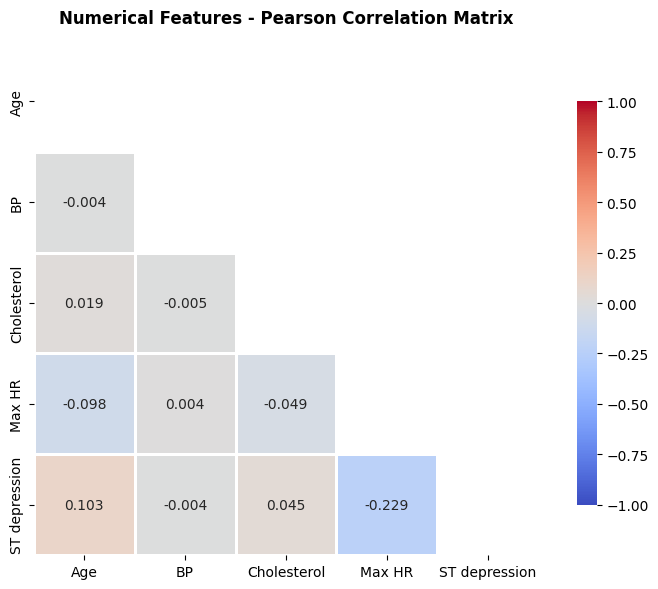

In [22]:
"""
NUMERICAL - NUMERICAL

PEARSON: Pearson correlation is used to measure linear relationships between numerical variables.

Interpretation guideline:
- |r| < 0.3 → Weak
- 0.3 ≤ |r| < 0.5 → Moderate
- |r| ≥ 0.5 → Strong

HEATMAP: It is used to quickly identify strong correlations and potential multicollinearity.

High correlations (> |0.5|) may indicate redundant predictors, which can negatively affect linear models.
"""

# Pearson correlation
corr_matrix = train[numerical_features].corr(method='pearson')

print(corr_matrix.round(3))

# Heat map
plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, square=True, 
            linewidths=1, cbar_kws={"shrink": 0.8},
            mask=mask)
plt.title('Numerical Features - Pearson Correlation Matrix', 
          fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

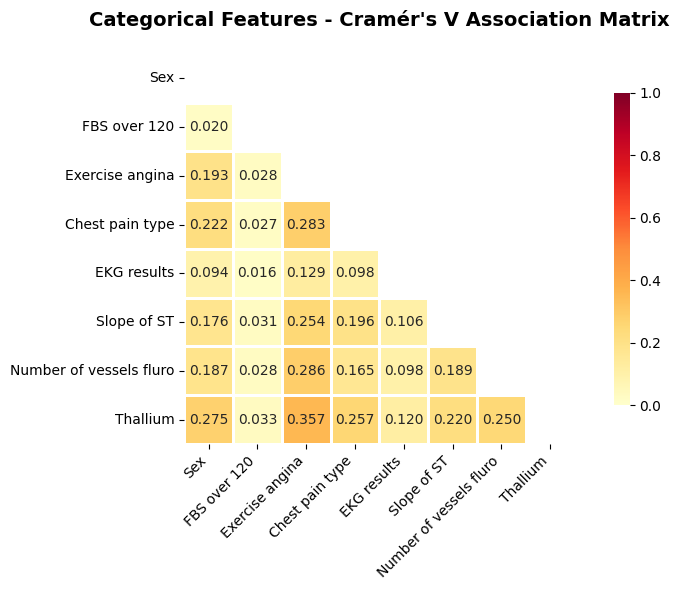

In [23]:
"""
CATEGORICAL - CATEGORICAL

Cramer's V and Heatmap.

Cramér’s V measures association strength between two categorical variables.

Interpretation guideline:
- < 0.10 → Negligible
- 0.10 – 0.30 → Small
- 0.30 – 0.50 → Medium
- > 0.50 → Strong

"""

# Create Cramér's V matrix
cramers_v_matrix = pd.DataFrame(index=categorical_features, 
                                columns=categorical_features, 
                                dtype=float)

for feat1 in categorical_features:
    for feat2 in categorical_features:
        if feat1 == feat2:
            cramers_v_matrix.loc[feat1, feat2] = 1.0
        else:
            contingency = pd.crosstab(train[feat1], train[feat2])
            chi2, _, _, _ = chi2_contingency(contingency)
            n = contingency.sum().sum()
            min_dim = min(contingency.shape[0] - 1, contingency.shape[1] - 1)
            cramers_v = np.sqrt(chi2 / (n * min_dim))
            cramers_v_matrix.loc[feat1, feat2] = cramers_v

cramers_v_matrix = cramers_v_matrix.astype(float)

# Heatmap Cramér's V matrix
plt.figure(figsize=(9, 6))
mask = np.triu(np.ones_like(cramers_v_matrix, dtype=bool))
sns.heatmap(cramers_v_matrix, annot=True, fmt='.3f', cmap='YlOrRd', 
            vmin=0, vmax=1, square=True, 
            linewidths=1, cbar_kws={"shrink": 0.8},
            mask=mask)
plt.title('Categorical Features - Cramér\'s V Association Matrix', 
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [24]:
"""
NUMERICAL - CATEGORICAL

The relationship between numerical and categorical variables is evaluated using:

- One-way ANOVA (mean differences across categories)
- Eta-squared (η²), representing effect size

Eta-squared interpretation:
- < 0.01 → Negligible
- 0.01 – 0.06 → Small
- 0.06 – 0.14 → Medium
- > 0.14 → Large
"""

numerical_categorical_results = []

for num_feat in numerical_features:
    for cat_feat in categorical_features:
        # Get groups
        groups = []
        categories = train[cat_feat].unique()
        
        for category in categories:
            group_data = train[train[cat_feat] == category][num_feat]
            groups.append(group_data)
        
        # Perform one-way ANOVA
        f_stat, p_value = f_oneway(*groups)
        
        # Calculate correlation ratio (eta-squared)
        grand_mean = train[num_feat].mean()
        ss_between = sum([len(group) * (group.mean() - grand_mean)**2 for group in groups])
        ss_total = sum([(x - grand_mean)**2 for x in train[num_feat]])
        eta_squared = ss_between / ss_total if ss_total > 0 else 0

       # Effect size interpretation
        if eta_squared < 0.01:
            effect = 'Negligible'
        elif eta_squared < 0.06:
            effect = 'Small'
        elif eta_squared < 0.14:
            effect = 'Medium'
        else:
            effect = 'Large'
        
        numerical_categorical_results.append({
            'Numerical': num_feat,
            'Categorical': cat_feat,
            'F-statistic': round(f_stat, 2),
            'p-value': f'{p_value:.4f}' if p_value >= 0.001 else '<0.001',
            'Eta-squared': round(eta_squared, 3),
            'Effect Size': effect,
        })

# Create DataFrame
num_cat_df = pd.DataFrame(numerical_categorical_results)

# Sort by eta-squared
num_cat_df = num_cat_df.sort_values('Eta-squared', ascending=False)
print(num_cat_df.to_string(index=False))

    Numerical             Categorical  F-statistic p-value  Eta-squared Effect Size
ST depression             Slope of ST     77712.07  <0.001        0.198       Large
ST depression                Thallium     35164.02  <0.001        0.100      Medium
       Max HR                Thallium     32765.72  <0.001        0.094      Medium
ST depression Number of vessels fluro     21166.95  <0.001        0.092      Medium
ST depression         Exercise angina     54134.56  <0.001        0.079      Medium
ST depression         Chest pain type     17129.36  <0.001        0.075      Medium
       Max HR         Chest pain type     14245.38  <0.001        0.064      Medium
       Max HR Number of vessels fluro     14005.16  <0.001        0.063      Medium
       Max HR         Exercise angina     37235.23  <0.001        0.056       Small
       Max HR             Slope of ST     15001.91  <0.001        0.045       Small
ST depression                     Sex     21361.04  <0.001        0.033     

## **📌 f. EDA conclusions**

### Dataset Structure

* The dataset contains 630,000 observations and 15 variables, including the target.
* No missing values were detected, ensuring data completeness and eliminating the need for imputation.

### Target Variable

Since the imbalance ratio is below 1.5, the dataset can be considered reasonably balanced.  

* Absence: 55.2%
* Presence: 44.8%
* Imbalance ratio: 1.23

### **Numerical features**

All numerical variables show statistical significance due to large sample size, but practical relevance varies.


✅ **Age**. **-->** Keep as-is.

* Most of the patients are between 48-60 years (mean = 54).
* Very low outlier percentage (0.2%).
* Nearly symmetric distribution (skew = -0.16) with platykurtic behavior (kurtosis = -0.57).
* Small-to-moderate effect: Older patients show higher disease risk (*r* = 0.212, Cohen’s d = 0.438).


🤷 **Blood pressure (BP)**. **-->** Limited predictive value. Consider mild transformation for linear models or keep for tree-based models.

* Relatively normal range.
* 1.4% upper outliers. It could be normal cause hypertension could be relevant in heart disease.
* Mild right skew (skew = 0.63) and slightly leptokutic behaviour (kurtosis = 0.93).
* Negligible practical effect (*r* ≈ 0.005, Cohen’s d ≈ 0.01).


🤷 **Cholesterol**. **-->**  Keep for modeling but expect limited contribution.

* Shows a high variability and some very high values (max. 564).
* 0.3% outliers
* Approximately symmetric (skew = 0.27) and mesokurtic behavior (kurtosis = 0.07).
* Negligible effect (*r* = 0.083, Cohen’s d = 0.167)


✅ **Max Heart Rate**. **-->**  Strong predictor. Keep as primary continuous feature.

* 2.3% of outliers, most of them low outliers.
*  Ranges between 71 and 202 bpm.
* Left-skewed (skew = -0.75) and mesokurtic behaviour (kurtosis = 0.20).
* Largest numerical effect. Strong negative association (*r* = -0.441) and large effect size (Cohen’s d = -0.973). Patients with heart disease achieve significantly lower maximum heart rates.


❌ **ST Depression**. **-->** Transformation recommended (log1p) for linear models. Strong predictor.

* 1.6% upper outliers, most of them upper outliers.
* Highly right-skewed (skew = 1.33) and leptokurtic behaviour (kurtosis = 1.37).
* Strong positive association (r = 0.431) and large effect size (Cohen’s d = 0.936)

Higher ST depression strongly increases disease probability.

 
### **Categorical features**

All categorical variables show statistical significance. However, effect sizes vary considerably.

✅ **Sex**. 

* Male-dominated dataset (71%) and have more risk.
* Moderate Effect: (Cramér’s V =  0.342).
        
❌ **FBS over 120**. 

* Only 8% of the sample shows Fasting Blood Sugar over 120. 
* Small Effect: (Cramér’s V =  0.034).

        
✅ **Exercise angina**. 

* A 27.4% experience Exercise-Induced Angina.
* People with exercice angina shows 80.6% of possibilities to suffer a heart dissease.
* Moderate Effect: (Cramér’s V =  0.442).

          
✅ **Chest pain type**. **-->** Recode – Create binary: Asymptomatic vs All Others

* The majority of patients are asymtomatics in relation with Chest Pain (52%) follow by non-anginal pain (31%). 
* Large Effect: (Cramér’s V = 0.525).

        
✅ **EKG Results**. * **-->** Create binary – Collapse LVH + ST-T vs Normal (ST-T too rare).

* Normal (50.8%) and Left ventricular hyperonphy are the most common values.
* Small Effect: (Cramér’s V =  0.022).

        
✅ **Slope of ST**. **-->** Keep as ordinal.

* Most common was 1 (57%). 
* Moderate Effect: (Cramér’s V =  0.430).

          
✅ **Number of vessels fluro**. **-->** Keep as ordinal.

* Most have 0 colored vessels (71%).
* Moderate Effect: (Cramér’s V =  0.463).


✅ **Thallium**. **-->** Create risk score: 3 --> 0, 6 --> 1, 7 --> 2

* 3 is the most common category (59%).
* Large Effect: (Cramér’s V = 0.606).
  

### **Features relationshps**
  
**Numerical - Numerical**. 

* No strong Pearson correlations detected (|r| < 0.5).
* Multicollinearity risk is low.

**Categorical - Categorical**. 

* Most associations are weak.
* *Thallium* - *Exercise Angina*. Moderate association (V = 0.357) but not strong enough to suggest redundancy.

**Numerical - Categorical**. 

* *ST depression* and *Slope of ST* strongest association (0.198).
* *ST depression* shows moderate association with *Thalliumm* and *Number of vessels*.
* Moderate association between *Max HR* and *Thallium*.


### **Final Implications for Modeling**

* Linear models require transformation for ST Depression and BP.
* Ordinal structure should be preserved where clinically meaningful.
* Tree-based models can naturally capture non-linear interactions.

# **🛠 3. Feature Engineering**

Feature engineering is performed based on insights derived from the Exploratory Data Analysis (EDA).

Two separate datasets are created:

* One optimized for regression models (logistic regression).
* One preserved for tree-based models.



In [25]:
"""
DATASET COPIES

* train_lr and test_lr are created for regression models.
* train_trees and test_trees are created for tree-based models.
"""

train_lr = train_raw.copy()
test_lr = test.copy()

train_trees = train_raw.copy()
test_trees = test.copy()

## **a. 📐Train regression models**

Since logistic regression assumes linear relationships and benefits from scaled predictors, several transformations are applied.

Based on EDA findings:

* Chest Pain Type → Re-coded into binary (Asymptomatic vs Others).
* EKG Results → Re-coded into binary (Normal vs Abnormal).
* Thallium → Converted into ordinal risk score (3 → 0, 6 → 1, 7 → 2).
* Ordinal structure is preserved.

Transformations are applied based on distributional properties:

* Age. Standardization (approximately symmetric distribution).
* BP. Log transformation + Standardization (mild right skew).
* Cholesterol. Standardization (weak skew, retained for completeness).
* Max Heart Rate. Standardization (strong predictive power).
* ST Depression. Log1p transformation + Standardization (high right skew and strong effect).

In [26]:
# Sex --> No need transformation
# FBS over 120 --> No need transformation
# Exercice angina --> No need transformation
# Slope of ST --> No need transformation
# Number of vessels fluro --> No need transformation

# Chest pain type --> Recode into Asymptomatic vs All others
train_lr["Chest pain type_bin"] = (train_lr["Chest pain type"] == 4).astype(int)

# EKG Results --> Recode into Normal vs Abnormal (ST-T + LVH)
train_lr["EKG results_bin"] = (train_lr["EKG results"] != 0).astype(int)

# Thallium --> Create risk score: 3 --> 0, 6 --> 1, 7 --> 2
mapping = {3: 0, 6: 1, 7: 2}
train_lr["Thallium_ord"] = train_lr["Thallium"].map(mapping)

# Age --> Standardize
scaler_age = StandardScaler()
train_lr["Age_std"] = scaler_age.fit_transform(train_lr[["Age"]])

# BP --> Log transformation + Standardize
train_lr["BP_log"] = np.log(train_lr["BP"])
scaler_bp = StandardScaler()
train_lr["BP_log_std"] = scaler_bp.fit_transform(train_lr[["BP_log"]])

# Cholesterol --> Standardize
scaler_chol = StandardScaler()
train_lr["Cholesterol_std"] = scaler_chol.fit_transform(train_lr[["Cholesterol"]])

# Max Heart Rate --> Standardiz
scaler_hr = StandardScaler()
train_lr["Max HR_std"] = scaler_hr.fit_transform(train_lr[["Max HR"]])

# ST Depression --> Log transformation + Standardize
train_lr["ST depression_log"] = np.log1p(train_lr["ST depression"])
scaler_st = StandardScaler()
train_lr["ST depression_log_std"] = scaler_st.fit_transform(train_lr[["ST depression_log"]])


In [27]:
"""
DROPPING REDUNDANT COLUMNS

Removing Redundant Variables
"""

cols_to_drop = [
    "Chest pain type", "EKG results", "Thallium", "Age", "BP", "BP_log", "Cholesterol", "Max HR",
    "ST depression", "ST depression_log"
]

train_lr = train_lr.drop(columns=cols_to_drop)

## **b. 🔁 Test regression models**

All scalers are fitted exclusively on the training set. The same fitted scalers are then applied to the test set.

In [28]:
# Sex --> No need transformation
# FBS over 120 --> No need transformation
# Exercice angina --> No need transformation
# Slope of ST --> No need transformation
# Number of vessels fluro --> No need transformation

# Chest pain type --> Recode into Asymptomatic vs All others
test_lr["Chest pain type_bin"] = (test_lr["Chest pain type"] == 4).astype(int)

# EKG Results --> Recode into Normal vs Abnormal (ST-T + LVH)
test_lr["EKG results_bin"] = (test_lr["EKG results"] != 0).astype(int)

# Thallium --> Create risk score: 3 --> 0, 6 --> 1, 7 --> 2
mapping = {3: 0, 6: 1, 7: 2}
test_lr["Thallium_ord"] = test_lr["Thallium"].map(mapping)

# Age --> Standardize
test_lr["Age_std"] = scaler_age.transform(test_lr[["Age"]])

# BP --> Log transformation + Standardize
test_lr["BP_log"] = np.log(test_lr["BP"])
test_lr["BP_log_std"] = scaler_bp.transform(test_lr[["BP_log"]])

# Cholesterol --> Standardize
test_lr["Cholesterol_std"] = scaler_chol.transform(test_lr[["Cholesterol"]])

# Max Heart Rate --> Standardiz
test_lr["Max HR_std"] = scaler_hr.transform(test_lr[["Max HR"]])

# ST Depression --> Log transformation + Standardize
test_lr["ST depression_log"] = np.log1p(test_lr["ST depression"])
test_lr["ST depression_log_std"] = scaler_st.transform(test_lr[["ST depression_log"]])

In [29]:
"""
DROPPING REDUNDANT COLUMNS

Removing Redundant Variables
"""

cols_to_drop = [
    "Chest pain type", "EKG results", "Thallium", "Age", "BP", "BP_log", "Cholesterol", "Max HR",
    "ST depression", "ST depression_log"
]

test_lr = test_lr.drop(columns=cols_to_drop)

## **c. 🎯 Final data**

The final steps include:

* Separating the target variable.
* Removing the *id* column from feature matrices.
* Storing test IDs for submission.
* Ensuring identical column order between train and test sets.
* Verifying column consistency.

In [30]:
# Target
y_train_lr = train_lr["Heart Disease"]
X_train_lr = train_lr.drop(columns=["Heart Disease"])

y_train_tree = train_trees["Heart Disease"]
X_train_tree = train_trees.drop(columns=["Heart Disease"])


X_test_lr = test_lr
X_test_tree = test_trees

In [31]:
# Id
test_ids = test["id"].copy() # Store

X_test_lr = X_test_lr.drop(columns=["id"])   # Remove
X_train_lr = X_train_lr.drop(columns=["id"])

X_test_tree = X_test_tree.drop(columns=["id"])   # Remove
X_train_tree = X_train_tree.drop(columns=["id"])

In [32]:
# Same order
X_test_lr   = X_test_lr[X_train_lr.columns]
X_test_tree = X_test_tree[X_train_tree.columns]

print(set(X_train_lr.columns) - set(X_test_lr.columns))
print(set(X_test_lr.columns) - set(X_train_lr.columns))

set()
set()


# 🤖 **4. Modeling**

This section evaluates multiple supervised classification models to predict heart disease.

The objective is to compare linear and tree-based approaches under the same cross-validation framework using ROC-AUC as the primary metric (competition requirement).

The following models are evaluated:

* Logistic Regression (L2 regularization)
* Logistic Regression (ElasticNet)
* Random Forest
* LightGBM

Model performance (mean ROC-AUC and standard deviation) is stored for final comparison.

In [33]:
# Save model results
results = []

## 🔹**a. Logistic Regression (L2 regularization)**

Logistic Regression with L2 regularization was implemented as a linear baseline model. This model serves as a benchmark against which more complex non-linear ensemble methods are compared.

L2 regularization penalizes large coefficients, helping to reduce overfitting while preserving all predictors.

The model was evaluated using 5-fold Stratified Cross-Validation to maintain class proportions across folds.

Hyperparameter tuning was performed on the regularization strength parameter (C), which controls the inverse of regularization intensity:

* Smaller C → stronger regularization
* Larger C → weaker regularization

In [34]:
# Cross-validation strategy
### Ensures each fold preserves the original class distribution.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Hyperparameter grid for regularization strength
param_grid = { "C": [0.001, 0.01, 0.1, 1, 10] }

# Grid Search with 5-fold CV
### Performs cross-validated hyperparameter tuning. Optimizes ROC-AUC across 5 folds.
grid_logreg = GridSearchCV(
    LogisticRegression(
        penalty="l2",             # Ridge regularization
        solver="lbfgs",           # Efficient for L2
        class_weight="balanced",  # Handle mild class imbalance
        max_iter=1000,            # Ensures convergence
        random_state=42
    ),
    param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

# Fit model
grid_logreg.fit(X_train_lr, y_train_lr)

# Extract best model statistics
best_index = grid_logreg.best_index_
best_std = grid_logreg.cv_results_["std_test_score"][best_index]

# Store results
results.append({
    "Model": "Logistic_L2",
    "Penalty": "L2",
    "Best_Params": grid_logreg.best_params_,
    "CV_ROC_AUC": grid_logreg.best_score_,
    "CV_STD": best_std
})

# Print results
print("Best C:", grid_logreg.best_params_)
print("Best CV ROC-AUC:", grid_logreg.best_score_)
print("Std:", best_std)

Best C: {'C': 0.01}
Best CV ROC-AUC: 0.9521157581492806
Std: 0.0003776621576261989


## 🔹 **b. Logistic Regression (ElasticNet)**

To evaluate whether combining L1 and L2 penalties improves predictive performance, Logistic Regression with ElasticNet regularization was implemented.

ElasticNet combines:

* L1 penalty (Lasso) → performs feature selection by shrinking some coefficients to zero.
* L2 penalty (Ridge) → stabilizes coefficients and reduces variance.

This combination is particularly useful when correlated predictors are present, as it balances sparsity and coefficient shrinkage.

Two hyperparameters were tuned:

* C → inverse regularization strength.
* l1_ratio → proportion of L1 penalty in the ElasticNet mix.

Performance was evaluated using ROC-AUC.

This model allows assessing whether introducing sparsity improves performance compared to pure L2 r

In [35]:
# Hyperparameter grid
param_grid = {
    "C": [0.01, 0.1, 1],         # Regularization strength
    "l1_ratio": [0.1, 0.3, 0.5]  # L1 vs L2 balance
}

# Grid Search
grid_en = GridSearchCV(
    LogisticRegression(
        penalty="elasticnet",   # Combined L1 + L2
        solver="saga",          # Required for ElasticNet
        max_iter=3000,          # Higher iterations for convergence
        class_weight="balanced",
        random_state=42
    ),
    param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

# Fit model
grid_en.fit(X_train_lr, y_train_lr)

# Extract statistics
best_index = grid_en.best_index_
best_std = grid_en.cv_results_["std_test_score"][best_index]

# Store results
results.append({
    "Model": "Logistic_ElasticNet",
    "Penalty": "ElasticNet",
    "Best_Params": grid_en.best_params_,
    "CV_ROC_AUC": grid_en.best_score_,
    "CV_STD": best_std
})

# Print results
print("Best Params:", grid_en.best_params_)
print("Best CV ROC-AUC:", grid_en.best_score_)
print("Std:", best_std)

Best Params: {'C': 0.01, 'l1_ratio': 0.3}
Best CV ROC-AUC: 0.9521157598802166
Std: 0.0003781452401163835


## 🔹 **c. Random Forest**

A Random Forest classifier was implemented to capture potential non-linear relationships and feature interactions.

Unlike linear models, Random Forest:

* Builds multiple decision trees using bootstrapped samples.
* Aggregates predictions via averaging (bagging).
* Reduces variance compared to single decision trees.
* Naturally captures non-linear effects and interaction patterns.

This model does not require feature scaling and is robust to monotonic transformations.

Performance was evaluated using ROC-AUC.

This model allows assessing whether non-linear ensemble methods outperform linear approaches in predicting heart disease risk.

In [36]:
# Hyperparameter grid
param_grid_rf = {
    "n_estimators": [200],      # Number of trees
    "max_depth": [10, 15],      # Tree depth control
    "min_samples_leaf": [1, 3]  # Leaf size regularization
}

# Grid Search
grid_rf = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        n_jobs=1  # Avoid double parallelization
    ),
    param_grid_rf,
    cv=cv,
    scoring="roc_auc",
    n_jobs=2     # Parallelize CV only here
)

# Fit model
grid_rf.fit(X_train_tree, y_train_tree)

# Extract statistics
best_index = grid_rf.best_index_
best_std = grid_rf.cv_results_["std_test_score"][best_index]

# Store results
results.append({
    "Model": "RandomForest",
    "Penalty": "None",
    "Best_Params": grid_rf.best_params_,
    "CV_ROC_AUC": grid_rf.best_score_,
    "CV_STD": best_std
})

# Print results
print("Best RF Params:", grid_rf.best_params_)
print("Best CV ROC-AUC:", grid_rf.best_score_)
print("Std:", best_std)

Best RF Params: {'max_depth': 15, 'min_samples_leaf': 3, 'n_estimators': 200}
Best CV ROC-AUC: 0.9529778719081422
Std: 0.00040696564776804056


## 🔹**d. LightGBM**

To capture complex non-linear interactions between predictors, a Gradient Boosting model (LightGBM) was implemented.

LightGBM builds trees sequentially, where each new tree focuses on correcting the residual errors of the previous ensemble.

Performance was measured using ROC-AUC.

LightGBM achieved the highest ROC-AUC among all evaluated models, indicating that heart disease risk prediction benefits from capturing complex non-linear interactions.

In [37]:
# Hyperparameter grid
param_grid_lgb = {
    "n_estimators": [400],    # Number of boosting rounds
    "learning_rate": [0.05],  # Step size shrinkage
    "num_leaves": [31],       # Tree complexity control
    "max_depth": [-1],        # Unlimited depth (controlled by num_leaves)
    "min_child_samples": [20] # Regularization parameter
}

# Grid Search
grid_lgb = GridSearchCV(
    lgb.LGBMClassifier(
        objective="binary",
        random_state=42,
        n_jobs=1  # Avoid double parallelization
    ),
    param_grid=param_grid_lgb,
    cv=cv,
    scoring="roc_auc",
    n_jobs=2
)

# Fit model
grid_lgb.fit(X_train_tree, y_train_tree)

# Extract statistics
best_index = grid_lgb.best_index_
best_std = grid_lgb.cv_results_["std_test_score"][best_index]

# Store results
results.append({
    "Model": "LightGBM",
    "Penalty": "None",
    "Best_Params": grid_lgb.best_params_,
    "CV_ROC_AUC": grid_lgb.best_score_,
    "CV_STD": best_std
})

# Print results
print("Best LGB Params:", grid_lgb.best_params_)
print("Best CV ROC-AUC:", grid_lgb.best_score_)
print("Std:", best_std)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 282454, number of negative: 347546
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.080428 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 417
[LightGBM] [Info] Number of data points in the train set: 630000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448340 -> initscore=-0.207381
[LightGBM] [Info] Start training from score -0.207381
Best LGB Params: {'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 400, 'num_leaves': 31}
Best CV ROC-AUC: 0.9551243279776681
Std: 0.0004336235398330957


## 🎯 **e. Model Comparison**

All evaluated models are compared using mean cross-validated ROC-AUC and standard deviation.

Models are ranked based on ROC-AUC performance to identify the best-performing approach under identical validation conditions.

In [38]:
results_df = (
    pd.DataFrame(results)
    .sort_values(by="CV_ROC_AUC", ascending=False)
    .reset_index(drop=True)
)

results_df

,Model,Penalty,Best_Params,CV_ROC_AUC,CV_STD
0,LightGBM,None,"{'learning_rate': 0.05, 'max_depth': -1, 'min_...",0.955124,0.000434
1,RandomForest,None,"{'max_depth': 15, 'min_samples_leaf': 3, 'n_es...",0.952978,0.000407
2,Logistic_ElasticNet,ElasticNet,"{'C': 0.01, 'l1_ratio': 0.3}",0.952116,0.000378
3,Logistic_L2,L2,{'C': 0.01},0.952116,0.000378


## 📌 **f. Models conclusions**


### Overall Interpretation

Given the competition metric (ROC-AUC), LightGBM is selected as the final model due to its superior ranking performance.

#### 🔹 LightGBM
LightGBM achieved the highest ROC-AUC (0.9551), outperforming all other models.  
This indicates that gradient boosting effectively captures non-linear interactions and subtle feature relationships in the dataset.  

The low standard deviation (0.000434) confirms high stability across folds.

#### 🔹 Random Forest
Random Forest achieved a ROC-AUC of 0.9530, slightly below LightGBM but above linear models.  
This suggests that non-linear interactions contribute to predictive performance, although bagging-based ensembles are slightly less powerful than boosting for this task.

The improvement over logistic regression confirms the presence of moderate non-linear structure.

#### 🔹 Logistic Regression (L2 and ElasticNet)
Both Logistic Regression variants achieved identical ROC-AUC (0.9521).  

# 🏆 **5. Final model**

Based on cross-validated performance comparison, **LightGBM** achieved the highest ROC-AUC and was selected as the final model.

The final configuration uses the best hyperparameters obtained during tuning and is trained on the full training dataset to maximize predictive power before generating test predictions.

The selected hyperparameters were:

* **learning_rate = 0.05**
* **n_estimators = 400**
* **num_leaves = 31**
* **max_depth = -1** (no explicit depth restriction)
* **min_child_samples = 20**

Since the competition requires probability outputs, predictions are generated using predict_proba, selecting the probability of the positive class.

In [39]:
# Final LightGBM model with best parameters

final_lgb = lgb.LGBMClassifier(
    objective="binary",
    learning_rate=0.05,
    n_estimators=400,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    random_state=42,
    n_jobs=-1
)

# Fit on full training data
final_lgb.fit(X_train_tree, y_train_tree)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 282454, number of negative: 347546
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.042321 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 417
[LightGBM] [Info] Number of data points in the train set: 630000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448340 -> initscore=-0.207381
[LightGBM] [Info] Start training from score -0.207381


LGBMClassifier(learning_rate=0.05, n_estimators=400, n_jobs=-1,
               objective='binary', random_state=42)

In [40]:
# Predict probabilities (class 1 = Presence)
test_pred_proba = final_lgb.predict_proba(X_test_tree)[:, 1]

In [41]:
# Submission field
submission = pd.DataFrame({
    "id": test_ids,
    "Heart Disease": test_pred_proba
})

submission.to_csv("submission.csv", index=False)

submission.head()

,id,Heart Disease
0,630000,0.949093
1,630001,0.009497
2,630002,0.985502
3,630003,0.006652
4,630004,0.176210


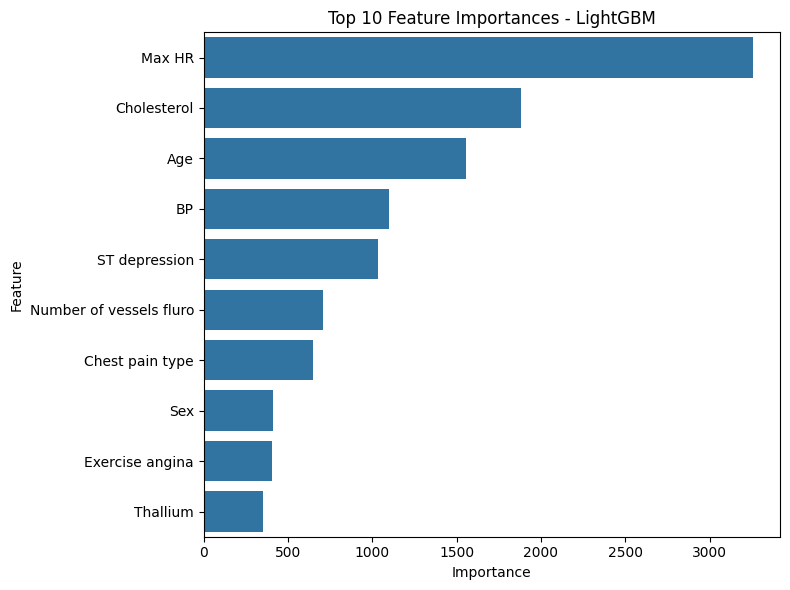

In [42]:
# Feature Importance Analysis
feature_importance = pd.DataFrame({
    "Feature": X_train_tree.columns,
    "Importance": final_lgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=feature_importance.head(10),
            x="Importance",
            y="Feature")
plt.title("Top 10 Feature Importances - LightGBM")
plt.tight_layout()
plt.show()